In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve, f1_score)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df=pd.read_csv("Default_Fin.csv")

#LOAD AND INSPECT DATA SET

In [3]:
print("Shape:", df.shape)
print("\n--- First 5 rows ---")
display(df.head())

Shape: (10000, 5)

--- First 5 rows ---


,Index,Employed,Bank Balance,Annual Salary,Defaulted?
0,1,1,8754.36,532339.56,0
1,2,0,9806.16,145273.56,0
2,3,1,12882.60,381205.68,0
3,4,1,6351.00,428453.88,0
4,5,1,9427.92,461562.00,0


In [4]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Index              int64
Employed           int64
Bank Balance     float64
Annual Salary    float64
Defaulted?         int64
dtype: object


In [5]:
print("\n--- Statistical Summary ---")
display(df.describe())


--- Statistical Summary ---


,Index,Employed,Bank Balance,Annual Salary,Defaulted?
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,0.705600,10024.498524,402203.782224,0.033300
std,2886.89568,0.455795,5804.579486,160039.674988,0.179428
min,1.00000,0.000000,0.000000,9263.640000,0.000000
25%,2500.75000,0.000000,5780.790000,256085.520000,0.000000
50%,5000.50000,1.000000,9883.620000,414631.740000,0.000000
75%,7500.25000,1.000000,13995.660000,525692.760000,0.000000
max,10000.00000,1.000000,31851.840000,882650.760000,1.000000


In [7]:
print("\n--- Target Distribution ---")
print(df['Defaulted?'].value_counts())


--- Target Distribution ---
Defaulted?
0    9667
1     333
Name: count, dtype: int64


In [8]:
df = df.drop(columns=['Index'])

In [9]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

=== Missing Values ===
Employed         0
Bank Balance     0
Annual Salary    0
Defaulted?       0
dtype: int64

Total missing: 0


In [10]:
if df.isnull().sum().sum() == 0:
    print("\n✅ No missing values — dataset is complete.")
else:
    numeric_cols = df.select_dtypes(include='number').columns
    cat_cols     = df.select_dtypes(include='object').columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    df[cat_cols]     = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
    print("\n⚠️ Missing values filled using median/mode strategy.")


✅ No missing values — dataset is complete.


#Visualize-Target and salary distribution

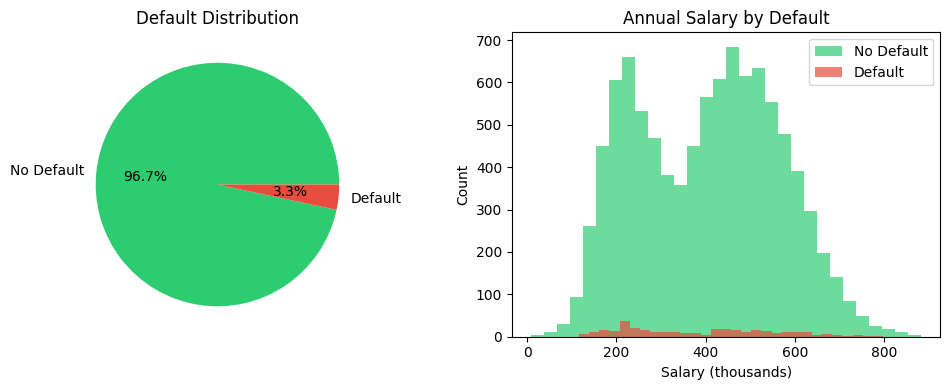

In [15]:

colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(10, 4))

# --- 1. Pie Chart ---
plt.subplot(1, 2, 1)
counts = df['Defaulted?'].value_counts()
plt.pie(counts,
        labels=['No Default', 'Default'],
        autopct='%1.1f%%',
        colors=colors)
plt.title('Default Distribution')

# --- 2. Histogram ---
plt.subplot(1, 2, 2)
plt.hist(df[df['Defaulted?'] == 0]['Annual Salary'] / 1000,
         bins=30, color=colors[0], alpha=0.7, label='No Default')

plt.hist(df[df['Defaulted?'] == 1]['Annual Salary'] / 1000,
         bins=30, color=colors[1], alpha=0.7, label='Default')

plt.title('Annual Salary by Default')
plt.xlabel('Salary (thousands)')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

#Visualize-Bank Balance and employement

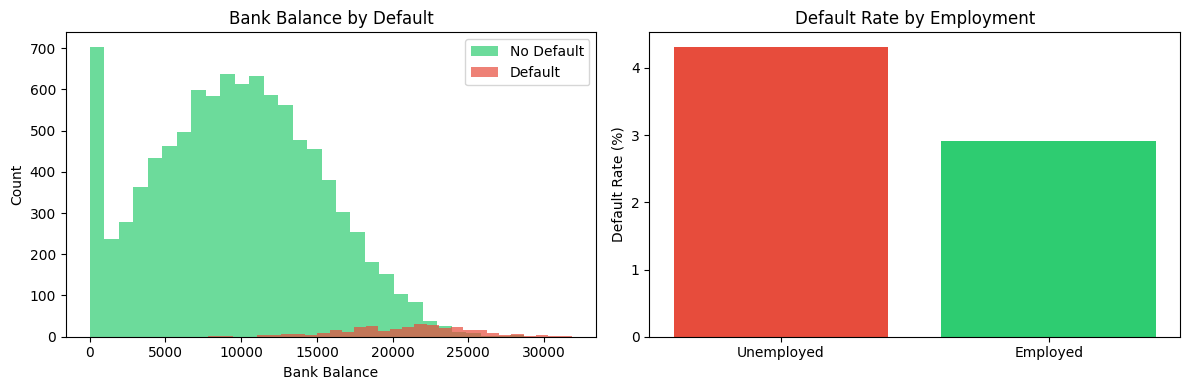

In [18]:
colors = ['#2ecc71', '#e74c3c']  # green, red

plt.figure(figsize=(12, 4))

# --- 1. Bank Balance Histogram ---
plt.subplot(1, 2, 1)

plt.hist(df[df['Defaulted?'] == 0]['Bank Balance'],
         bins=30, color=colors[0], alpha=0.7, label='No Default')

plt.hist(df[df['Defaulted?'] == 1]['Bank Balance'],
         bins=30, color=colors[1], alpha=0.7, label='Default')

plt.title('Bank Balance by Default')
plt.xlabel('Bank Balance')
plt.ylabel('Count')
plt.legend()

# --- 2. Default Rate by Employment ---
plt.subplot(1, 2, 2)

rates = df.groupby('Employed')['Defaulted?'].mean() * 100

plt.bar(['Unemployed', 'Employed'],
        rates.values,
        color=[colors[1], colors[0]])  # red = bad, green = good

plt.title('Default Rate by Employment')
plt.ylabel('Default Rate (%)')

plt.tight_layout()
plt.show()

# Coorrelation Heat Map

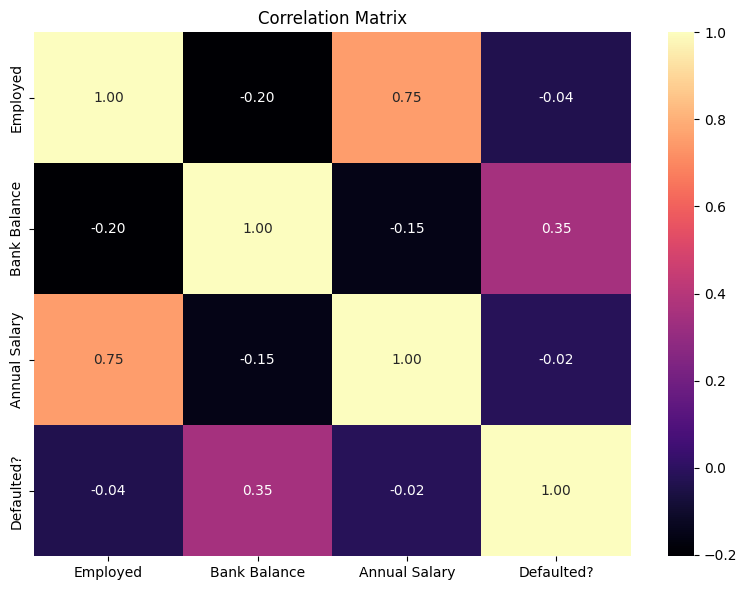

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

corr = df[['Employed', 'Bank Balance', 'Annual Salary', 'Defaulted?']].corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='magma')

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

#Feature Engineering and Train-Test Split

In [27]:
# Feature engineering
df['Salary_to_Balance_Ratio'] = df['Annual Salary'] / (df['Bank Balance'] + 1)
df['Log_Salary'] = np.log1p(df['Annual Salary'])
df['Log_Balance'] = np.log1p(df['Bank Balance'])

# Split features and target
X = df.drop(columns=['Defaulted?'])
y = df['Defaulted?']

# Train-test split (keeps class ratio same)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Basic info
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("Train default rate:", round(y_train.mean() * 100, 2), "%")
print("Test default rate:", round(y_test.mean() * 100, 2), "%")

Training samples: 8000
Testing samples: 2000
Train default rate: 3.32 %
Test default rate: 3.35 %


#Logistic Regression

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Model
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Train
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]

# Results
print("Logistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, lr_pred), 4))
print("F1-Score:", round(f1_score(y_test, lr_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_proba), 4))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['No Default', 'Default']))

Logistic Regression Results
Accuracy: 0.8555
F1-Score: 0.2899
ROC-AUC: 0.9485

Classification Report:
              precision    recall  f1-score   support

  No Default       1.00      0.85      0.92      1933
     Default       0.17      0.88      0.29        67

    accuracy                           0.86      2000
   macro avg       0.58      0.87      0.60      2000
weighted avg       0.97      0.86      0.90      2000



#Decision Tree

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Model
dt_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ))
])

# Train
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]

# Results
print("Decision Tree Results")
print("Accuracy:", round(accuracy_score(y_test, dt_pred), 4))
print("F1-Score:", round(f1_score(y_test, dt_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, dt_proba), 4))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=['No Default', 'Default']))

Decision Tree Results
Accuracy: 0.8375
F1-Score: 0.2597
ROC-AUC: 0.9209

Classification Report:
              precision    recall  f1-score   support

  No Default       0.99      0.84      0.91      1933
     Default       0.15      0.85      0.26        67

    accuracy                           0.84      2000
   macro avg       0.57      0.84      0.58      2000
weighted avg       0.97      0.84      0.89      2000



#Support Vector

In [31]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1, gamma='scale', probability=True))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_proba = svm_model.predict_proba(X_test)[:, 1]

# Results
print("Decision Tree Results")
print("Accuracy:", round(accuracy_score(y_test, dt_pred), 4))
print("F1-Score:", round(f1_score(y_test, dt_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, dt_proba), 4))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred, target_names=['No Default', 'Default']))

Decision Tree Results
Accuracy: 0.8375
F1-Score: 0.2597
ROC-AUC: 0.9209

Classification Report:
              precision    recall  f1-score   support

  No Default       0.99      0.84      0.91      1933
     Default       0.15      0.85      0.26        67

    accuracy                           0.84      2000
   macro avg       0.57      0.84      0.58      2000
weighted avg       0.97      0.84      0.89      2000



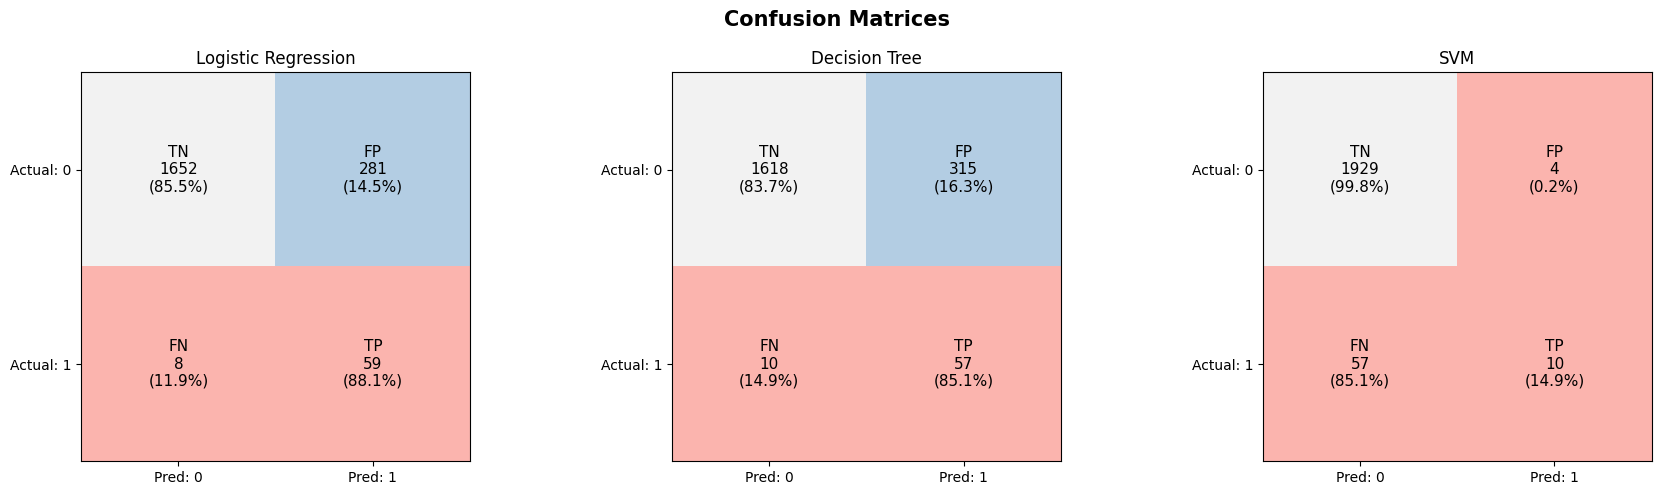

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=15, fontweight='bold')

models = [
    (lr_pred, 'Logistic Regression'),
    (dt_pred, 'Decision Tree'),
    (svm_pred, 'SVM')
]

for ax, (pred, name) in zip(axes, models):

    cm = confusion_matrix(y_test, pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

    im = ax.imshow(cm, cmap='Pastel1')

    labels = [['TN', 'FP'], ['FN', 'TP']]

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i,
                f"{labels[i][j]}\n{cm[i, j]}\n({cm_pct[i, j]:.1f}%)",
                ha='center',
                va='center',
                fontsize=11
            )

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: 0', 'Pred: 1'])
    ax.set_yticklabels(['Actual: 0', 'Actual: 1'])
    ax.set_title(name)

plt.tight_layout()
plt.show()

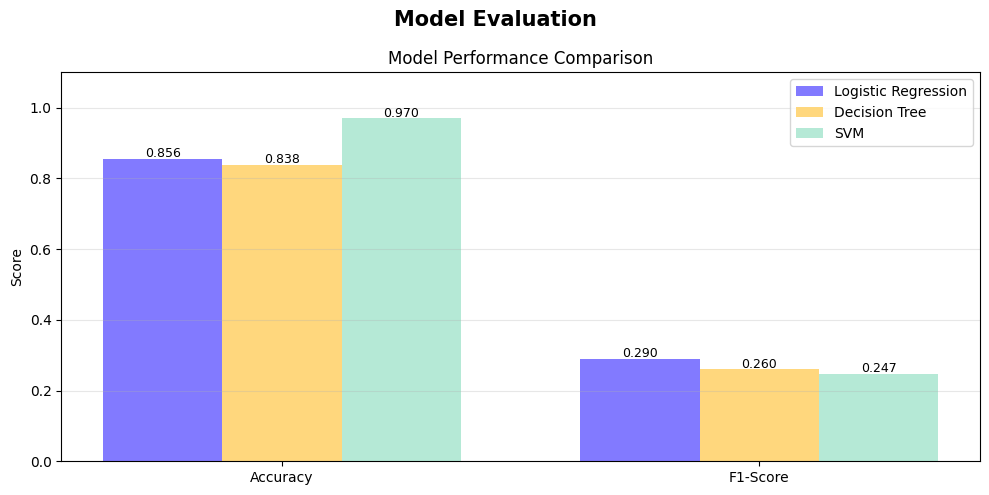

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Model Evaluation', fontsize=15, fontweight='bold')

# Metrics
metrics = ['Accuracy', 'F1-Score']

lr_vals  = [accuracy_score(y_test, lr_pred), f1_score(y_test, lr_pred)]
dt_vals  = [accuracy_score(y_test, dt_pred), f1_score(y_test, dt_pred)]
svm_vals = [accuracy_score(y_test, svm_pred), f1_score(y_test, svm_pred)]

x = np.arange(len(metrics))
w = 0.25

# Bars
b1 = ax.bar(x - w, lr_vals,  w, label='Logistic Regression', color='#6C63FF', alpha=0.85)
b2 = ax.bar(x,      dt_vals, w, label='Decision Tree',      color='#FFD166', alpha=0.85)
b3 = ax.bar(x + w,  svm_vals, w, label='SVM',               color='#A8E6CF', alpha=0.85)

# Value labels
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center',
            fontsize=9
        )

# Styling
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()